In [1]:
import pandas as pd

df = pd.read_csv("../data/energy_dataset.csv")
df.head()


,surface_area,wall_area,roof_area,glazing_area,height,compactness,orientation,energy_class
0,274,378,272,19,4.702751,0.530007,4,1
1,339,359,175,18,4.972581,0.817926,1,0
2,314,297,140,17,3.809120,0.644334,2,0
3,332,448,170,17,5.141293,0.680344,4,0
4,313,342,260,28,4.652013,0.756585,2,1


In [2]:
df.shape


(5000, 8)

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   surface_area  5000 non-null   int64  
 1   wall_area     5000 non-null   int64  
 2   roof_area     5000 non-null   int64  
 3   glazing_area  5000 non-null   int64  
 4   height        5000 non-null   float64
 5   compactness   5000 non-null   float64
 6   orientation   5000 non-null   int64  
 7   energy_class  5000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 312.6 KB


In [4]:
df.describe()


,surface_area,wall_area,roof_area,glazing_area,height,compactness,orientation,energy_class
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,204.994800,296.979000,189.041000,22.017000,3.966727,0.751081,2.499000,0.49100
std,84.449791,115.159417,63.670434,10.029558,0.871372,0.141972,1.113125,0.60827
min,60.000000,100.000000,80.000000,5.000000,2.500358,0.500037,1.000000,0.00000
25%,132.000000,197.000000,133.000000,13.000000,3.210989,0.631370,2.000000,0.00000
50%,206.000000,297.000000,189.000000,22.000000,3.948918,0.750931,2.000000,0.00000
75%,279.000000,398.000000,244.000000,31.000000,4.720554,0.872326,3.000000,1.00000
max,349.000000,499.000000,299.000000,39.000000,5.499744,0.999992,4.000000,2.00000


In [5]:
df.isna().sum()


surface_area    0
wall_area       0
roof_area       0
glazing_area    0
height          0
compactness     0
orientation     0
energy_class    0
dtype: int64

In [6]:
df.duplicated().sum()


np.int64(0)

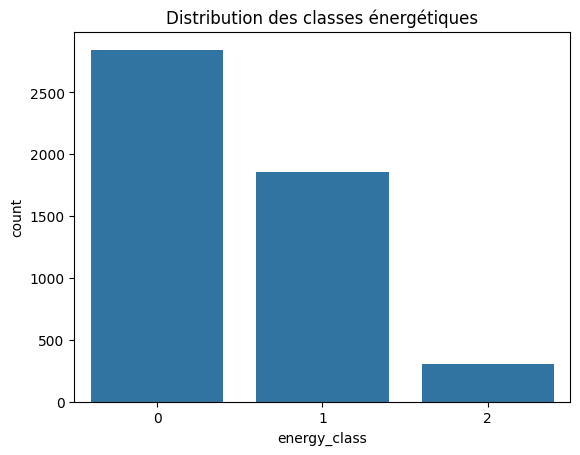

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="energy_class", data=df)
plt.title("Distribution des classes énergétiques")
plt.show()


In [9]:
df["energy_class"].value_counts(normalize=True)


energy_class
0    0.569
1    0.371
2    0.060
Name: proportion, dtype: float64

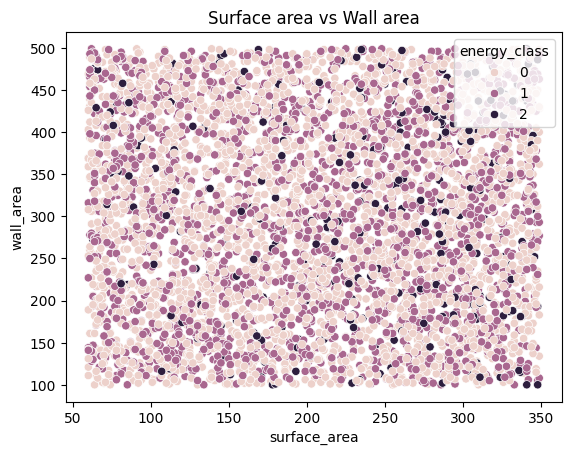

In [10]:
sns.scatterplot(data=df, x="surface_area", y="wall_area", hue="energy_class")
plt.title("Surface area vs Wall area")
plt.show()


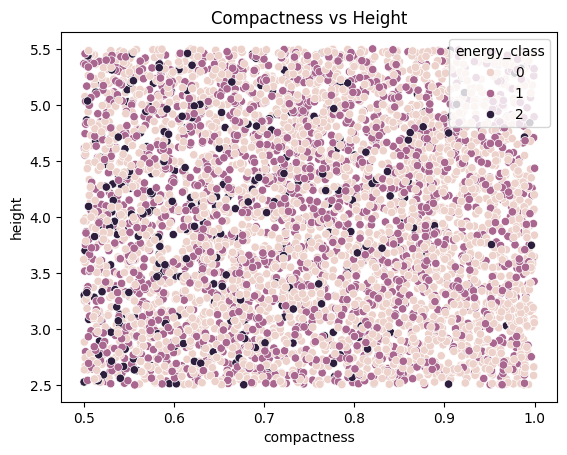

In [11]:
sns.scatterplot(data=df, x="compactness", y="height", hue="energy_class")
plt.title("Compactness vs Height")
plt.show()


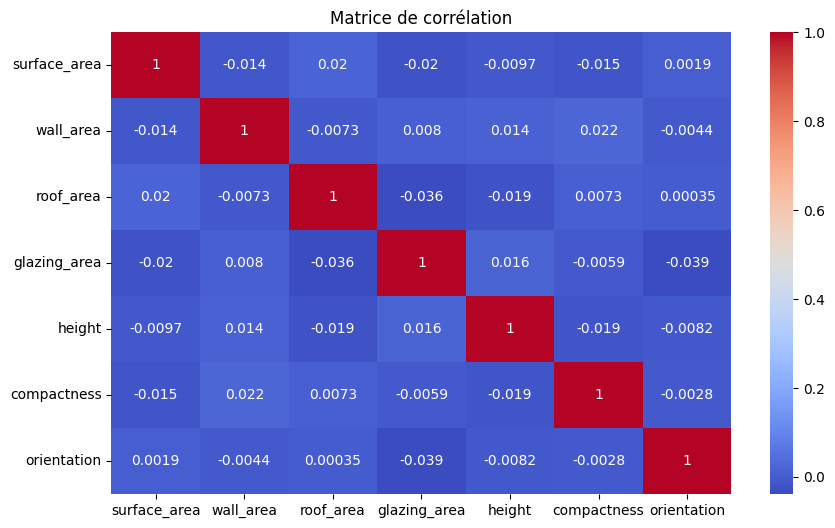

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns=["energy_class"]).corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()


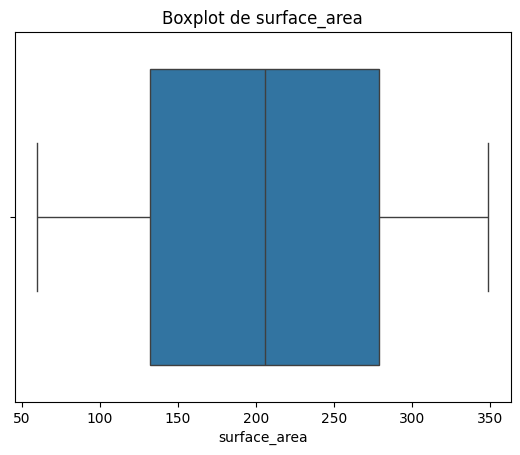

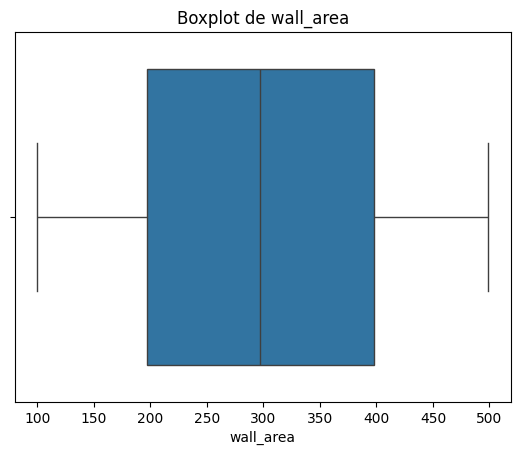

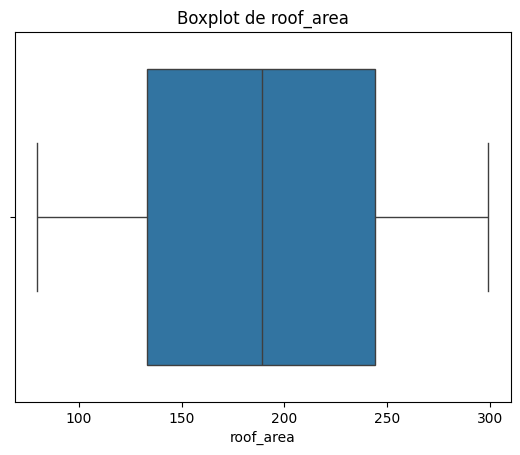

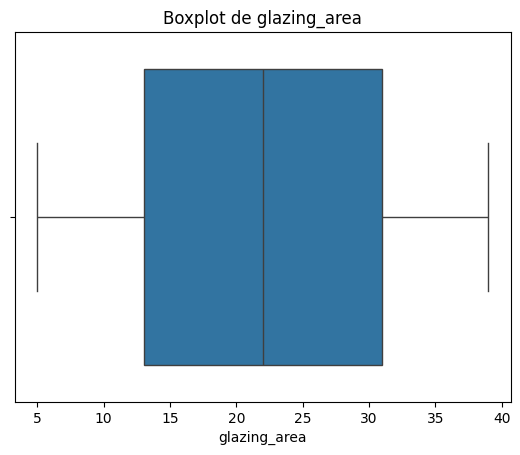

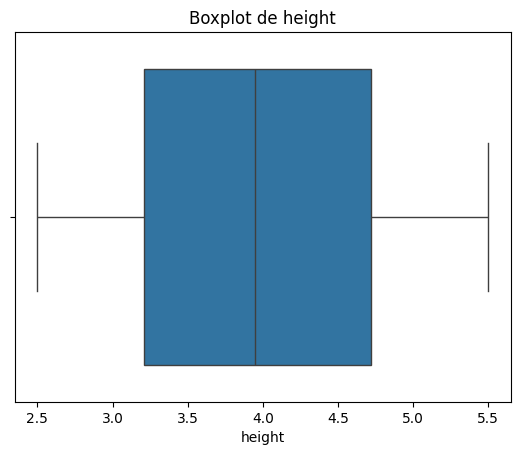

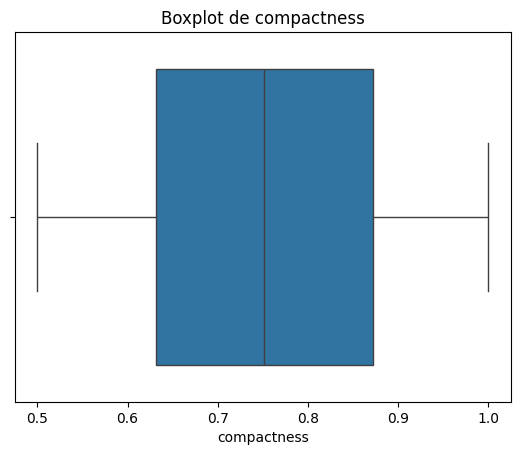

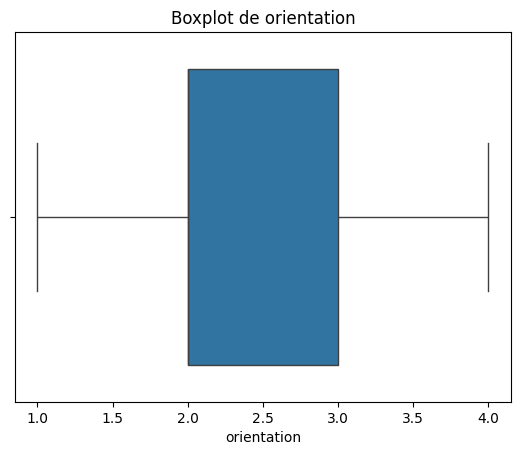

In [13]:
for col in df.columns:
    if col != "energy_class":
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot de {col}")
        plt.show()


In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["energy_class"])
y = df["energy_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((4000, 7), (1000, 7))

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preprocess = Pipeline([
    ("scaler", StandardScaler())
])

preprocess


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
